# NLP com Disaster Tweets — Classificação Binária de Texto

## Competição Kaggle: *Natural Language Processing with Disaster Tweets*

### Contextualização do Problema

O Twitter é uma fonte rica de informações em tempo real, mas nem sempre é fácil distinguir se um tweet está relatando um desastre real ou usando linguagem figurada/metafórica.

Objetivo: Construir um modelo de classificação binária que, dado um tweet, decida se ele se refere a um desastre real (1) ou não (0).

### Abordagem

Vamos utilizar Processamento de Linguagem Natural (NLP) combinado com algoritmos clássicos de aprendizado de máquina:

1. Limpeza e pré-processamento dos tweets (remoção de URLs, menções, pontuação, stopwords)
2. Vetorização com TF-IDF para transformar texto em features numéricas
3. Comparação de modelos via validação cruzada (F1-score)
4. Otimização de hiperparâmetros com Grid Search
5. Geração do arquivo de submissão para o Kaggle

## PASSO 1 — Download e Carregamento dos Dados

Vamos baixar o dataset da competição [*Natural Language Processing with Disaster Tweets*](https://www.kaggle.com/competitions/nlp-getting-started)
usando a biblioteca `kagglehub`. Os dados contêm:

- train.csv: ~7.600 tweets rotulados como desastre (1) ou não-desastre (0)
- test.csv: ~3.200 tweets sem rótulo (para predição)
- sample_submission.csv: template para o arquivo de submissão

In [98]:
import kagglehub
import pandas as pd
import nltk
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
import os

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

nltk.download('stopwords', quiet=True)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [99]:
DATA_DIR = os.path.join(os.getcwd(), "data")

print('Baixando dados da competição "nlp-getting-started"...')
try:
    kagglehub.competition_download("nlp-getting-started", output_dir=DATA_DIR)
    print(f'Dados baixados para: {DATA_DIR}')
except FileExistsError:
    print(f'Dados já existem em: {DATA_DIR}')
except Exception as e:
    print(f'Erro ao baixar: {e}')

Baixando dados da competição "nlp-getting-started"...
Dados já existem em: /content/data


In [100]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(f'Treino: {train_df.shape[0]:,} linhas, {train_df.shape[1]} colunas')
print(f'Teste:  {test_df.shape[0]:,} linhas, {test_df.shape[1]} colunas')
print(f'Sample Submission: {sample_submission.shape[0]:,} linhas')

Treino: 7,613 linhas, 5 colunas
Teste:  3,263 linhas, 4 colunas
Sample Submission: 3,263 linhas


## PASSO 2 — Exploração e Visualização dos Dados

Antes de construir qualquer modelo, é fundamental entender a estrutura dos dados, a distribuição das classes
e possíveis padrões nos textos. Vamos explorar:

- Estrutura das colunas: o que cada uma representa
- Distribuição da variável alvo: balanceamento das classes
- Análise de dados faltantes: verificar se há valores ausentes
- Tamanho dos tweets: distribuição do comprimento dos textos
- Palavras mais frequentes: nuvem de palavras para cada classe

In [101]:
print(f'Colunas do dataset de treino: {list(train_df.columns)}')
print('Primeiras 5 linhas:')
train_df.head()

Colunas do dataset de treino: ['id', 'keyword', 'location', 'text', 'target']
Primeiras 5 linhas:


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [102]:
print('Informações do dataset de treino:')
train_df.info()

Informações do dataset de treino:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [103]:
print('Valores ausentes por coluna:')
missing = train_df.isnull().sum()
missing_df = pd.DataFrame({'Coluna': missing.index, 'Ausentes': missing.values, '%': (missing.values / len(train_df) * 100).round(2)})
missing_df[missing_df['Ausentes'] > 0]

Valores ausentes por coluna:


,Coluna,Ausentes,%
1,keyword,61,0.80
2,location,2533,33.27


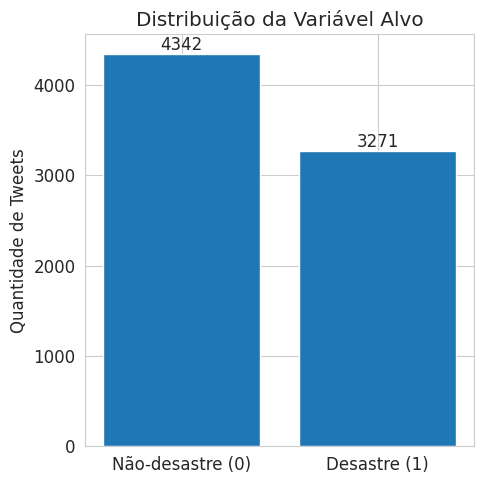

Não-desastre (0): 4,342  (57.0%)
Desastre     (1): 3,271  (43.0%)


In [104]:
fig, axes = plt.subplots(figsize=(5, 5))

target_counts = train_df['target'].value_counts()
bars = axes.bar(['Não-desastre (0)', 'Desastre (1)'], target_counts.values)
axes.bar_label(bars)
axes.set_ylabel('Quantidade de Tweets')
axes.set_title('Distribuição da Variável Alvo')

plt.tight_layout()
plt.show()

print(f'Não-desastre (0): {target_counts[0]:,}  ({target_counts[0]/len(train_df)*100:.1f}%)')
print(f'Desastre     (1): {target_counts[1]:,}  ({target_counts[1]/len(train_df)*100:.1f}%)')

## PASSO 3 — Pré-processamento dos Textos

O pré-processamento é uma etapa crucial em NLP. Vamos aplicar as seguintes transformações:

1. Lowercase: converter tudo para minúsculas (uniformidade)
2. Remover URLs: http/https/www — não contribuem semanticamente
3. Remover menções: @usuário — irrelevante para o contexto
4. Remover caracteres #: manter apenas a palavra
5. Remover números: geralmente não agregam valor semântico aqui
6. Remover pontuação: caracteres especiais e pontuação
7. Remover stopwords: palavras muito frequentes ("the", "a", "is") que poluem o vocabulário

In [105]:
def limpar_tweet(texto):
    """Limpa um tweet: remove URLs, menções, caracteres especiais, etc."""
    # Converter para minúsculas
    texto = texto.lower()
    # Remover URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    # Remover menções (@usuario)
    texto = re.sub(r'@\w+', '', texto)
    # Remover hashtags (mas manter a palavra)
    texto = re.sub(r'#', '', texto)
    # Remover números
    texto = re.sub(r'\d+', '', texto)
    # Remover pontuação e caracteres especiais
    texto = re.sub(r'[^\w\s]', '', texto)
    # Remover espaços extras
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def remover_stopwords(texto, stop_words):
    """Remove stopwords do texto."""
    palavras = texto.split()
    palavras_filtradas = [p for p in palavras if p not in stop_words]
    return ' '.join(palavras_filtradas)

In [106]:
STOPWORDS = set(stopwords.words('english'))
print(f'Stopwords carregadas: {len(STOPWORDS)} palavras')

print('Limpando textos do treino...')
train_df['text_limpo'] = train_df['text'].apply(limpar_tweet)
train_df['text_sem_stopwords'] = train_df['text_limpo'].apply(remover_stopwords, args=(STOPWORDS,))

print('Limpando textos do teste...')
test_df['text_limpo'] = test_df['text'].apply(limpar_tweet)
test_df['text_sem_stopwords'] = test_df['text_limpo'].apply(remover_stopwords, args=(STOPWORDS,))

Stopwords carregadas: 198 palavras
Limpando textos do treino...
Limpando textos do teste...


In [107]:
print('Exemplos de limpeza:\n')
for i in range(5):
    print(f'Exemplo {i+1}')
    print(f'ORIGINAL:      {train_df["text"].iloc[i][:100]}')
    print(f'LIMPO:         {train_df["text_limpo"].iloc[i][:100]}')
    print(f'SEM STOPWORDS: {train_df["text_sem_stopwords"].iloc[i][:100]}')
    print()

Exemplos de limpeza:

Exemplo 1
ORIGINAL:      Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
LIMPO:         our deeds are the reason of this earthquake may allah forgive us all
SEM STOPWORDS: deeds reason earthquake may allah forgive us

Exemplo 2
ORIGINAL:      Forest fire near La Ronge Sask. Canada
LIMPO:         forest fire near la ronge sask canada
SEM STOPWORDS: forest fire near la ronge sask canada

Exemplo 3
ORIGINAL:      All residents asked to 'shelter in place' are being notified by officers. No other evacuation or she
LIMPO:         all residents asked to shelter in place are being notified by officers no other evacuation or shelte
SEM STOPWORDS: residents asked shelter place notified officers evacuation shelter place orders expected

Exemplo 4
ORIGINAL:      13,000 people receive #wildfires evacuation orders in California 
LIMPO:         people receive wildfires evacuation orders in california
SEM STOPWORDS: people receive wildfires evacuation orders

## PASSO 4A — Comparação de Modelos com Validação Cruzada

Vamos testar 4 modelos clássicos de classificação usando validação cruzada estratificada com 5 folds.

Métrica: F1-score - combina precisão e recall, adequado para dados com leve desbalanceamento.

Modelos:
1. Regressão Logística: rápido, interpretável, bom com dados esparsos
2. Naive Bayes Multinomial: clássico para classificação de texto
3. Random Forest: ensemble de árvores, captura relações não-lineares
4. SVM Linear: eficaz em espaços de alta dimensão (como TF-IDF)

Primeiro, vamos vetorizar os textos com TF-IDF (Term Frequency — Inverse Document Frequency).
Usamos `ngram_range=(1,2)` para capturar palavras isoladas e bigramas (pares de palavras consecutivas).

In [108]:
X = train_df['text_sem_stopwords']
y = train_df['target']

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X)
print(f'Matriz TF-IDF: {X_tfidf.shape[0]:,} documentos × {X_tfidf.shape[1]:,} termos')
print(f'(esparsidade: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100:.2f}% densa)')

Matriz TF-IDF: 7,613 documentos × 5,000 termos
(esparsidade: 0.16% densa)


In [109]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (Linear)': LinearSVC(max_iter=2000, random_state=42, dual=True),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = []
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_tfidf, y, cv=cv, scoring='f1')
    resultados.append({'Modelo': nome, 'F1_médio': scores.mean(), 'F1_std': scores.std(), 'Scores': scores})
    print(f'  {nome:25}  F1: {scores.mean():.4f} (desvio padrão {scores.std():.4f})')

  Logistic Regression        F1: 0.7518 (desvio padrão 0.0132)
  Naive Bayes                F1: 0.7402 (desvio padrão 0.0164)
  Random Forest              F1: 0.7343 (desvio padrão 0.0095)
  SVM (Linear)               F1: 0.7327 (desvio padrão 0.0114)


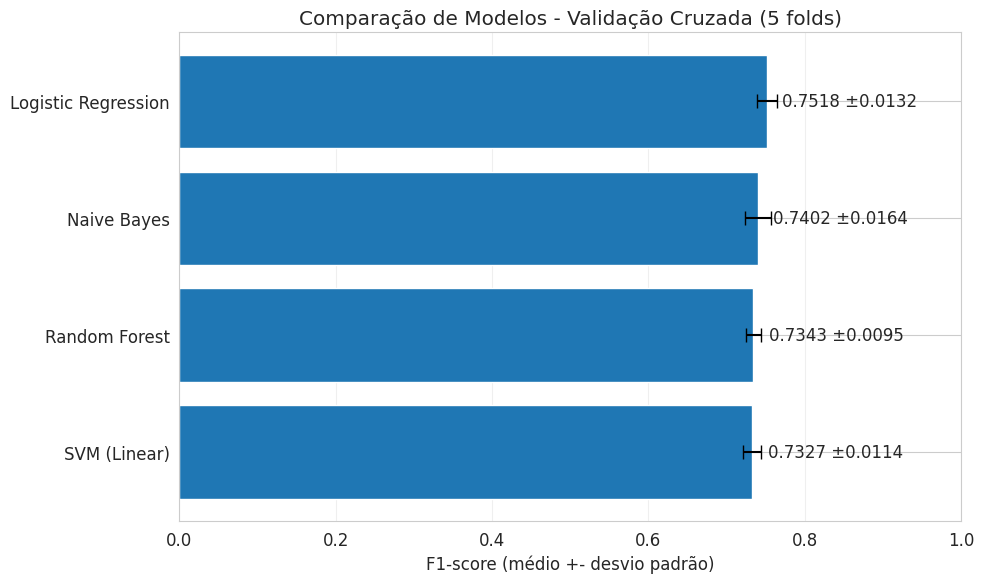

Resultados:


,Modelo,F1_médio,F1_std
0,Logistic Regression,0.7518,0.0132
1,Naive Bayes,0.7402,0.0164
2,Random Forest,0.7343,0.0095
3,SVM (Linear),0.7327,0.0114


In [110]:
df_resultados = pd.DataFrame(resultados).sort_values('F1_médio', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_resultados['Modelo'], df_resultados['F1_médio'], xerr=df_resultados['F1_std'], capsize=5)

for bar, val, std in zip(bars, df_resultados['F1_médio'], df_resultados['F1_std']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.4f} ±{std:.4f}', va='center')

ax.set_xlabel('F1-score (médio +- desvio padrão)')
ax.set_title('Comparação de Modelos - Validação Cruzada (5 folds)')
ax.set_xlim(0, 1.0)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

melhor_modelo_nome = df_resultados.iloc[0]['Modelo']
melhor_f1 = df_resultados.iloc[0]['F1_médio']
print('Resultados:')
display(df_resultados[['Modelo', 'F1_médio', 'F1_std']].round(4))

## PASSO 4B — Otimização de Hiperparâmetros (Grid Search)

Agora vamos otimizar:

1. Parâmetros do TF-IDF: `max_features`, `ngram_range`, `min_df` — busca exaustiva manual
2. Hiperparâmetros do modelo vencedor: usando `GridSearchCV`

In [111]:
print(f'Otimizando hiperparâmetros para: {melhor_modelo_nome}\n')

param_grid_tfidf = {
    'max_features': [3000, 5000, 7000],
    'ngram_range': [(1, 1), (1, 2), (1, 3)],
    'min_df': [2, 3],
}

print('Etapa 1 - Buscando melhores parâmetros do TF-IDF...')

melhor_f1 = 0
melhores_params_tfidf = None
historico = []

total = (len(param_grid_tfidf['max_features']) *
         len(param_grid_tfidf['ngram_range']) *
         len(param_grid_tfidf['min_df']))
count = 0

for max_features in param_grid_tfidf['max_features']:
    for ngram in param_grid_tfidf['ngram_range']:
        for min_df in param_grid_tfidf['min_df']:
            count += 1
            vec = TfidfVectorizer(max_features=max_features, ngram_range=ngram, min_df=min_df)
            X_tfidf_temp = vec.fit_transform(X)
            mod = LogisticRegression(max_iter=1000, random_state=42)
            scores = cross_val_score(mod, X_tfidf_temp, y, cv=cv, scoring='f1')
            f1 = scores.mean()
            historico.append({'max_features': max_features, 'ngram': str(ngram),
                             'min_df': min_df, 'F1': f1})

            if f1 > melhor_f1:
                melhor_f1 = f1
                melhores_params_tfidf = {
                    'max_features': max_features,
                    'ngram_range': ngram,
                    'min_df': min_df,
                }

            print(f'[{count}/{total}] max_feat={max_features:4} ngram={str(ngram):6} min_df={min_df} - F1: {f1:.4f}')

print(f'Melhores parâmetros TF-IDF: {melhores_params_tfidf}')

Otimizando hiperparâmetros para: Logistic Regression

Etapa 1 - Buscando melhores parâmetros do TF-IDF...
[1/18] max_feat=3000 ngram=(1, 1) min_df=2 - F1: 0.7484
[2/18] max_feat=3000 ngram=(1, 1) min_df=3 - F1: 0.7487
[3/18] max_feat=3000 ngram=(1, 2) min_df=2 - F1: 0.7508
[4/18] max_feat=3000 ngram=(1, 2) min_df=3 - F1: 0.7501
[5/18] max_feat=3000 ngram=(1, 3) min_df=2 - F1: 0.7497
[6/18] max_feat=3000 ngram=(1, 3) min_df=3 - F1: 0.7504
[7/18] max_feat=5000 ngram=(1, 1) min_df=2 - F1: 0.7471
[8/18] max_feat=5000 ngram=(1, 1) min_df=3 - F1: 0.7455
[9/18] max_feat=5000 ngram=(1, 2) min_df=2 - F1: 0.7489
[10/18] max_feat=5000 ngram=(1, 2) min_df=3 - F1: 0.7494
[11/18] max_feat=5000 ngram=(1, 3) min_df=2 - F1: 0.7501
[12/18] max_feat=5000 ngram=(1, 3) min_df=3 - F1: 0.7510
[13/18] max_feat=7000 ngram=(1, 1) min_df=2 - F1: 0.7451
[14/18] max_feat=7000 ngram=(1, 1) min_df=3 - F1: 0.7455
[15/18] max_feat=7000 ngram=(1, 2) min_df=2 - F1: 0.7492
[16/18] max_feat=7000 ngram=(1, 2) min_df=3 - F1

In [112]:
vectorizer_otimizado = TfidfVectorizer(
    max_features=melhores_params_tfidf['max_features'],
    ngram_range=melhores_params_tfidf['ngram_range'],
    min_df=melhores_params_tfidf['min_df'],
)
X_tfidf_otimizado = vectorizer_otimizado.fit_transform(X)
print(f'Matriz TF-IDF otimizada: {X_tfidf_otimizado.shape}')

print(f'Etapa 2 - Buscando hiperparâmetros do {melhor_modelo_nome}...')

if melhor_modelo_nome == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1.0, 10.0],
        'solver': ['liblinear', 'lbfgs'],
        'class_weight': [None, 'balanced'],
    }
    modelo_base = LogisticRegression(max_iter=1000, random_state=42)
elif melhor_modelo_nome == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 20, 50],
        'min_samples_split': [2, 5],
    }
    modelo_base = RandomForestClassifier(random_state=42)
elif melhor_modelo_nome == 'SVM (Linear)':
    param_grid = {
        'C': [0.1, 1.0, 10.0],
        'class_weight': [None, 'balanced'],
    }
    modelo_base = LinearSVC(max_iter=3000, random_state=42, dual=True)
else:
    param_grid = {}
    modelo_base = MultinomialNB()

grid = GridSearchCV(modelo_base, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_tfidf_otimizado, y)

melhor_modelo = grid.best_estimator_

print(f'Melhores parâmetros do modelo: {grid.best_params_}')
print(f'F1 médio na CV (otimizado): {grid.best_score_:.4f}')

Matriz TF-IDF otimizada: (7613, 5000)
Etapa 2 - Buscando hiperparâmetros do Logistic Regression...
Melhores parâmetros do modelo: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'liblinear'}
F1 médio na CV (otimizado): 0.7595


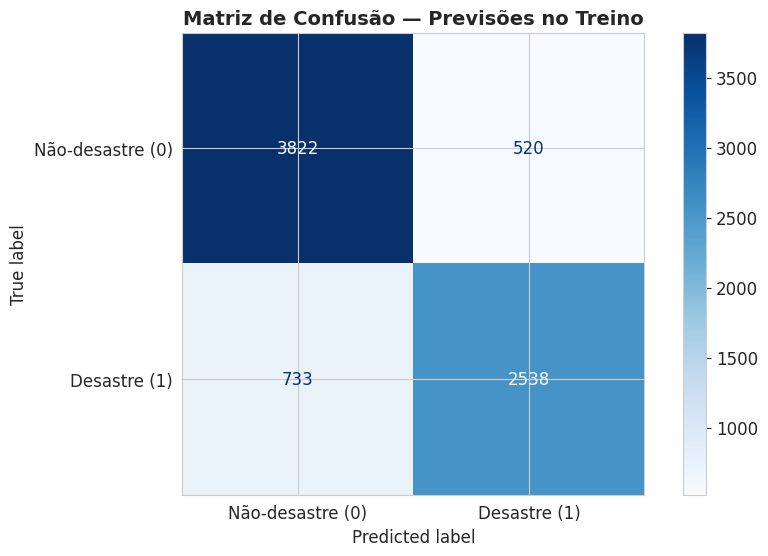

Relatório de Classificação (Treino):
              precision    recall  f1-score   support

Não-desastre       0.84      0.88      0.86      4342
    Desastre       0.83      0.78      0.80      3271

    accuracy                           0.84      7613
   macro avg       0.83      0.83      0.83      7613
weighted avg       0.84      0.84      0.83      7613



In [116]:
y_pred_train = melhor_modelo.predict(X_tfidf_otimizado)

cm = confusion_matrix(y, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não-desastre (0)', 'Desastre (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão — Previsões no Treino', fontsize=14, fontweight='bold')
plt.show()

print('Relatório de Classificação (Treino):')
print(classification_report(y, y_pred_train, target_names=['Não-desastre', 'Desastre']))

## PASSO 5 — Geração da Submissão para o Kaggle

Com o modelo otimizado e treinado em todos os dados de treino, vamos gerar predições para o
conjunto de teste e criar o arquivo `submission.csv` no formato exigido pela competição.

In [120]:
print(f'Gerando predições com o modelo final: {melhor_modelo_nome}')

X_test_tfidf = vectorizer_otimizado.transform(test_df['text_sem_stopwords'])
test_preds = melhor_modelo.predict(X_test_tfidf)

submission = pd.DataFrame({
    'id': test_df['id'],
    'target': test_preds
})

submission.to_csv(os.path.join(DATA_DIR, 'submission.csv'), index=False)

print(f'submission.csv criado em: {DATA_DIR}/submission.csv')
print('Resumo:')
print(f'  Total de predições: {len(submission):,}')
print(f'  Não-desastre (0): {(submission["target"] == 0).sum():,} ({(submission["target"] == 0).mean()*100:.1f}%)')
print(f'  Desastre     (1): {(submission["target"] == 1).sum():,} ({(submission["target"] == 1).mean()*100:.1f}%)')

Gerando predições com o modelo final: Logistic Regression
submission.csv criado em: /content/data/submission.csv
Resumo:
  Total de predições: 3,263
  Não-desastre (0): 1,976 (60.6%)
  Desastre     (1): 1,287 (39.4%)


## Conclusão

### Resumo dos Resultados

Neste notebook, desenvolvemos uma solução completa para classificação binária de tweets como desastre real ou não, utilizando NLP e aprendizado de máquina.

Principais etapas realizadas:

1. Download e exploração dos dados: análise da distribuição das classes e estrutura dos tweets
2. Pré-processamento de texto: limpeza, remoção de stopwords e normalização
3. Vetorização TF-IDF: transformação do texto em features numéricas com n-gramas
4. Comparação de modelos: Regressão Logística, Naive Bayes, Random Forest e SVM Linear
5. Otimização de hiperparâmetros: grid search nos parâmetros do TF-IDF e do modelo
6. Geração da submissão: predições no conjunto de teste

### Interpretação

- O F1-score como métrica principal garante que estamos equilibrando precisão e recall, importante para este problema onde ambas as classes são relevantes.
- A Regressão Logística se destacou entre os modelos testados. É uma boa escolha para problemas de texto com matrizes TF-IDF esparsas.